# 08 — Focal model SHAP 심층 분석 (logret_rank LGB)

단일 focal 모델: `logret_rank | F4_noylag_nodz | LGB`  (MAE 198.35, RW ratio 0.968)

외생-only (y_lag 없음, delta_zero 없음) 조건에서 RW를 ~3% 이긴 유일 후보군 중 best.

분석 마스크 (06 노트북과 동일):
- phase별 (train phase2 / train phase3 / test phase4)
- 상승/하락일 (test ret > 0 / < 0)

06 노트북과의 차이:
- target: ret_1d_raw rank → log1p(ret_1d_raw) rank (logret_rank)
- feature_set: F4_noylag_nodz (y_lag 제외, delta_zero 제외, ret memory도 제외)
- model 1개

In [1]:
# ---------- 0. Header / Config ----------
import os, sys, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 123
PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
MASTER_PATH = PROJECT_ROOT / 'data' / 'features' / 'master_full_nontime.csv'
EXT_PATH = PROJECT_ROOT / 'data' / 'features' / 'master_full_nontime_ext.csv'
PARENT_OUT = PROJECT_ROOT / 'reports' / 'metrics' / 'nontime' / 'logret_2t2f'
PARENT_FIG = PROJECT_ROOT / 'reports' / 'figures' / 'nontime' / 'logret_2t2f'
OUT_DIR = PARENT_OUT / 'focal'
FIG_DIR = PARENT_FIG / 'focal'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.nontime_helpers import (
    YEARS_FIT, YEARS_HP, YEARS_FINAL, YEARS_TEST,
    TREE_MODELS,
    split_by_year,
    fit_predict, evaluation_reg, evaluation_reg_trte,
    shap_values_tree, shap_share_table,
    ECDFRanker,
    restore_pred_close_v2, common_metrics_v2,
)

# best params from logret_2t2f run
with open(PARENT_OUT / 'best_params.json', 'r', encoding='utf-8') as f:
    BEST_PARAMS = json.load(f)

FOCAL_TARGET = 'logret_rank'
FOCAL_FSET   = 'F4_noylag_nodz'
FOCAL_MODEL  = 'LGB'
FOCAL_KEY = f'{FOCAL_TARGET}|{FOCAL_FSET}|{FOCAL_MODEL}'
print('best params:', BEST_PARAMS[FOCAL_KEY])

# core 5 (06과 동일)
CORE5 = ['Oman_roll5_mean', 'Dubai', 'ask_ratio_last', 'KRX_SEMICON', 'VIX_KR']
print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUT_DIR =', OUT_DIR)
print('FIG_DIR =', FIG_DIR)

best params: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 400}
PROJECT_ROOT = C:\Users\JONJI\cli\KAU_Prediction
OUT_DIR = C:\Users\JONJI\cli\KAU_Prediction\reports\metrics\nontime\logret_2t2f\focal
FIG_DIR = C:\Users\JONJI\cli\KAU_Prediction\reports\figures\nontime\logret_2t2f\focal


In [2]:
# ---------- 1. Feature set / target helpers (07과 동일 정의) ----------
ALWAYS_EXCLUDE = [
    'date', 'front_vintage', 'phase',
    'KAU_CLOSE', 'value', 'volume',
    'delta_1d', 'ret_1d_raw', 'delta_zero',
]
Y_LAG_COLS = [
    'KAU_CLOSE_lag1', 'KAU_CLOSE_lag2', 'KAU_CLOSE_lag3',
    'KAU_CLOSE_roll5_mean', 'KAU_CLOSE_roll20_mean', 'KAU_CLOSE_roll60_mean',
    'KAU_CLOSE_roll5_std', 'KAU_CLOSE_roll20_std',
]
DZ_COLS = [
    'delta_zero_lag1', 'delta_zero_lag2', 'delta_zero_lag3',
    'delta_zero_roll5_rate', 'delta_zero_roll20_rate',
    'delta_zero_streak_lag1', 'days_since_delta_zero',
    'zero_to_nonzero_lag1', 'nonzero_to_zero_lag1',
]
OWN_SCALE_EXCLUDE = [
    'delta_lag1', 'delta_lag2', 'delta_lag3',
    'delta_roll5_mean', 'delta_roll5_std',
    'delta_roll20_mean', 'delta_roll20_std',
    'ret_lag1_raw', 'ret_lag2_raw', 'ret_lag3_raw',
    'ret_roll5_mean_raw', 'ret_roll5_std_raw',
    'ret_roll20_mean_raw', 'ret_roll20_std_raw',
]

def build_feature_columns(df_, feature_set):
    cols = [c for c in df_.columns
            if c not in ALWAYS_EXCLUDE
            and c not in OWN_SCALE_EXCLUDE
            and c not in Y_LAG_COLS]  # F4_noylag
    if '_nodz' in feature_set:
        cols = [c for c in cols if c not in DZ_COLS]
    return cols

def plot_prediction(y_true, y_pred, title, save_path=None):
    yt = np.asarray(y_true).reshape(-1)
    yp = np.asarray(y_pred).reshape(-1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(yt, label='actual', lw=1)
    ax[0].plot(yp, label='pred', lw=1, alpha=0.8)
    ax[0].legend(); ax[0].set_title(f'{title} | line'); ax[0].set_xlabel('idx (test, time order)')
    ax[1].scatter(yt, yp, s=10, alpha=0.6)
    lo = float(min(yt.min(), yp.min())); hi = float(max(yt.max(), yp.max()))
    ax[1].plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax[1].set_xlabel('actual'); ax[1].set_ylabel('pred'); ax[1].set_title(f'{title} | scatter')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

def share_under_mask(shap_arr, X, mask):
    sv = np.asarray(shap_arr)[mask]
    Xm = X.iloc[mask] if hasattr(X, 'iloc') else X[mask]
    if sv.shape[0] == 0:
        return pd.DataFrame({'feature': list(Xm.columns), 'mean_abs_shap': np.nan, 'share': np.nan})
    return shap_share_table(sv, list(Xm.columns)).rename(columns={'mean_abs_shap_share': 'share'})

print('helpers defined.')

helpers defined.


In [3]:
# ---------- 2. Data + Split ----------
df_base = pd.read_csv(MASTER_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
df_ext = pd.read_csv(EXT_PATH, parse_dates=['date'])
df = df_base.merge(df_ext, on='date', how='left')
df = df[df['date'].dt.year >= 2018].reset_index(drop=True)
df = df.dropna().reset_index(drop=True)
assert df.isna().sum().sum() == 0
assert (df['ret_1d_raw'] > -1).all()

df_fit, df_hp, df_final, df_test = split_by_year(df, seed=SEED)
print('shape:', df.shape, '| fit/hp/final/test:', len(df_fit), len(df_hp), len(df_final), len(df_test))

PHASE_COLS = ['phase_phase1', 'phase_phase2', 'phase_phase3', 'phase_phase4']
for c in PHASE_COLS:
    assert c in df.columns, f'missing {c}'

feats_check = build_feature_columns(df, FOCAL_FSET)
in_X = [c for c in PHASE_COLS if c in feats_check]
print('phase cols in X:', in_X)
print('feature count (F4_noylag_nodz):', len(feats_check))

year_to_phase = {2018:'phase2', 2019:'phase2', 2020:'phase2',
                 2021:'phase3', 2022:'phase3', 2023:'phase3', 2024:'phase3', 2025:'phase3',
                 2026:'phase4'}
y = df['date'].dt.year
for yr, ph in year_to_phase.items():
    sub = df[y == yr]
    if len(sub) == 0: continue
    col = f'phase_{ph}'
    assert (sub[col] == 1).all(), f'{yr} -> {ph} mismatch'
print('phase <-> year sanity OK')

shape: (2035, 125) | fit/hp/final/test: 1721 242 1963 72
phase cols in X: ['phase_phase1', 'phase_phase2', 'phase_phase3', 'phase_phase4']
feature count (F4_noylag_nodz): 85
phase <-> year sanity OK


In [4]:
# ---------- 3. Focal 모델 재학습 (best params 고정) ----------
def fit_focal_single(target, fset, model_name, params, df_fit, df_hp, df_final, df_test, seed=SEED):
    feats = build_feature_columns(df_fit, fset)
    Xtr = df_final[feats].copy()
    Xte = df_test[feats].copy()
    assert list(Xtr.columns) == list(Xte.columns)

    # logret_rank: ECDF on log1p(ret) of final fold
    logret_final = np.log1p(df_final['ret_1d_raw'].values.astype(float))
    logret_test  = np.log1p(df_test['ret_1d_raw'].values.astype(float))
    ranker = ECDFRanker().fit(logret_final)
    ytr = np.clip(ranker.transform(logret_final), 0.0, 1.0)
    yte = np.clip(ranker.transform(logret_test),  0.0, 1.0)

    model, ytrp, ytep = fit_predict(model_name, params, Xtr, ytr, Xte, seed=seed)
    ytrp_eval = np.clip(ytrp, 0.0, 1.0)
    ytep_eval = np.clip(ytep, 0.0, 1.0)

    nat = evaluation_reg_trte(ytr, ytrp_eval, yte, ytep_eval)
    nat['target'] = target; nat['fset'] = fset; nat['model'] = model_name
    nat = nat.reset_index().rename(columns={'index': 'split'})

    restored = restore_pred_close_v2(target, ytep_eval, df_test['KAU_CLOSE_lag1'].values, ranker=ranker)
    cm = common_metrics_v2(
        actual_close=df_test['KAU_CLOSE'].values,
        lag1_close=df_test['KAU_CLOSE_lag1'].values,
        pred_close=restored['pred_close'],
        pred_delta=restored['pred_delta'],
        pred_return=restored['pred_return'],
        vintage_transition=df_test['vintage_transition'].values.astype(bool),
        auction_window5=df_test['auction_window5'].values.astype(int),
    )
    cm.update({'target': target, 'fset': fset, 'model': model_name})

    return {
        'target': target, 'fset': fset, 'model': model_name, 'params': params,
        'feats': feats, 'model_obj': model, 'ranker': ranker,
        'X_train': Xtr, 'X_test': Xte,
        'y_train': ytr, 'y_test': yte,
        'y_train_pred': ytrp_eval, 'y_test_pred': ytep_eval,
        'pred_close_test': restored['pred_close'],
        'pred_delta_test': restored['pred_delta'],
        'pred_return_test': restored['pred_return'],
        'native': nat, 'common': cm,
    }

focal = {}
params = BEST_PARAMS[FOCAL_KEY]
print(f'[fit] {FOCAL_TARGET} | {FOCAL_FSET} | {FOCAL_MODEL} | params={params}')
focal[(FOCAL_TARGET, FOCAL_FSET, FOCAL_MODEL)] = fit_focal_single(
    FOCAL_TARGET, FOCAL_FSET, FOCAL_MODEL, params,
    df_fit, df_hp, df_final, df_test,
)
for k, r in focal.items():
    print(k, 'common:', {kk: (round(v, 4) if isinstance(v, float) else v)
                          for kk, v in r['common'].items() if kk not in ('target','fset','model')})

[fit] logret_rank | F4_noylag_nodz | LGB | params={'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 400}


('logret_rank', 'F4_noylag_nodz', 'LGB') common: {'pred_close_MAE': 198.3538, 'pred_close_RMSE': 286.0607, 'delta_MAE': 198.3538, 'return_MAE': 0.0144, 'rw_ratio_MAE': 0.9682, 'rw_ratio_RMSE': 0.9762, 'direction_acc': 0.4167, 'nonzero_direction_acc': 0.4032, 'zero_day_MAE': 17.8228, 'nonzero_day_MAE': 227.4716, 'auction_window5_MAE': 192.6601, 'non_auction_window5_MAE': 200.5436}


In [5]:
# ---------- 4. Train/Test 성능 비교 ----------
nat_all = pd.concat([r['native'] for r in focal.values()], axis=0).reset_index(drop=True)
com_all = pd.DataFrame([r['common'] for r in focal.values()])

nat_all.to_csv(OUT_DIR / 'focal_native_metrics.csv', index=False)
com_all.to_csv(OUT_DIR / 'focal_common_metrics.csv', index=False)

print('=== focal native (Train/Test) ===')
display(nat_all.set_index(['target','fset','model','split'])[['MAE','RMSE','R2']].round(4))

print('=== focal common (KAU_CLOSE 환원, Test) ===')
display(com_all.set_index(['target','fset','model']).round(4))

=== focal native (Train/Test) ===


MAE    RMSE      R2
target      fset           model split                        
logret_rank F4_noylag_nodz LGB   Train  0.0272  0.0370  0.9833
                                 Test   0.2630  0.3046 -0.0596

=== focal common (KAU_CLOSE 환원, Test) ===


,,,pred_close_MAE,pred_close_RMSE,delta_MAE,return_MAE,rw_ratio_MAE,rw_ratio_RMSE,direction_acc,nonzero_direction_acc,zero_day_MAE,nonzero_day_MAE,auction_window5_MAE,non_auction_window5_MAE
target,fset,model,,,,,,,,,,,,
logret_rank,F4_noylag_nodz,LGB,198.3538,286.0607,198.3538,0.0144,0.9682,0.9762,0.4167,0.4032,17.8228,227.4716,192.6601,200.5436


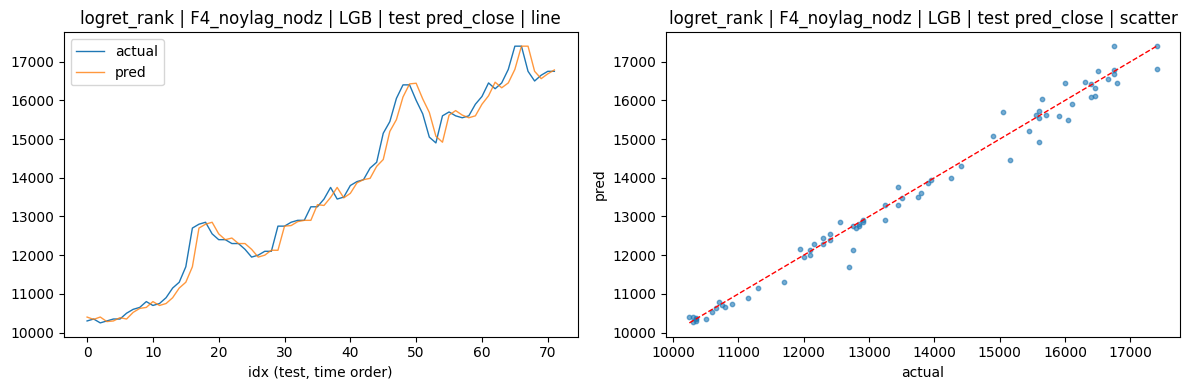

In [6]:
# ---------- 5. Test 예측 시각화 ----------
actual_close_te = df_test['KAU_CLOSE'].values
for (target, fset, model), r in focal.items():
    save = FIG_DIR / f'pred_focal_{target}_{fset}_{model}.png'
    plot_prediction(actual_close_te, r['pred_close_test'],
                    title=f'{target} | {fset} | {model} | test pred_close', save_path=save)

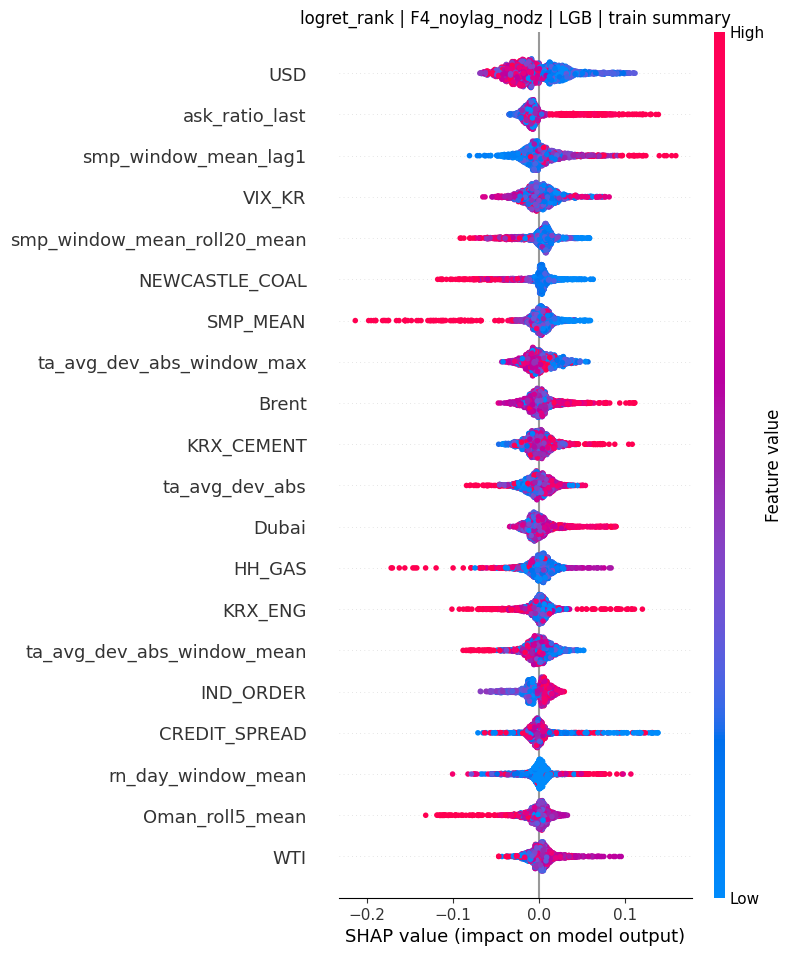

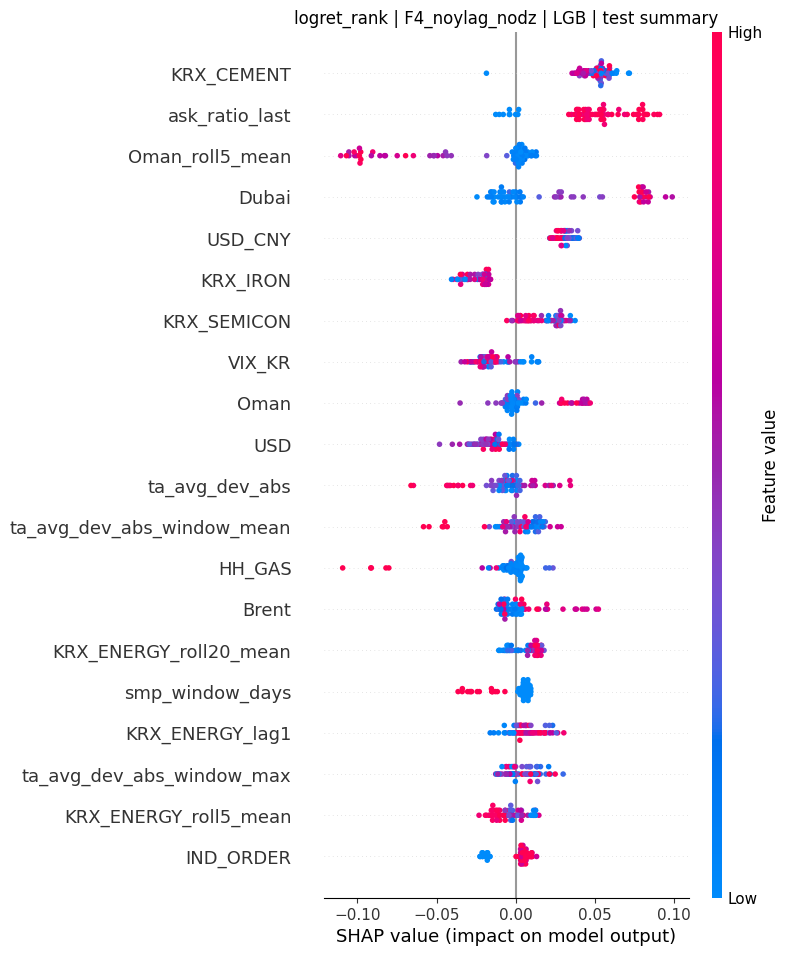

logret_rank | F4_noylag_nodz | LGB: test top10 = ['KRX_CEMENT', 'ask_ratio_last', 'Oman_roll5_mean', 'Dubai', 'USD_CNY', 'KRX_IRON', 'KRX_SEMICON', 'VIX_KR', 'Oman', 'USD']


In [7]:
# ---------- 6. SHAP 기본 — train/test summary + share csv ----------
import shap

shap_store = {}
for (target, fset, model), r in focal.items():
    Xtr = r['X_train']; Xte = r['X_test']
    sv_tr = shap_values_tree(r['model_obj'], Xtr)
    sv_te = shap_values_tree(r['model_obj'], Xte)
    shap_store[(target, fset, model)] = {'sv_train': sv_tr, 'sv_test': sv_te,
                                          'X_train': Xtr, 'X_test': Xte}

    tab_tr = shap_share_table(sv_tr, list(Xtr.columns))
    tab_te = shap_share_table(sv_te, list(Xte.columns))
    tab_tr.to_csv(OUT_DIR / f'focal_shap_meanabs_{target}_{fset}_{model}_train.csv', index=False)
    tab_te.to_csv(OUT_DIR / f'focal_shap_meanabs_{target}_{fset}_{model}_test.csv', index=False)

    plt.figure()
    shap.summary_plot(sv_tr, Xtr, show=False)
    plt.title(f'{target} | {fset} | {model} | train summary')
    plt.savefig(FIG_DIR / f'shap_summary_train_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
    plt.show()

    plt.figure()
    shap.summary_plot(sv_te, Xte, show=False)
    plt.title(f'{target} | {fset} | {model} | test summary')
    plt.savefig(FIG_DIR / f'shap_summary_test_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f'{target} | {fset} | {model}: test top10 =', tab_te['feature'].head(10).tolist())

logret_rank | F4_noylag_nodz | LGB: dep targets (7) = ['Oman_roll5_mean', 'Dubai', 'ask_ratio_last', 'KRX_SEMICON', 'VIX_KR', 'KRX_CEMENT', 'USD_CNY']


<Figure size 640x480 with 0 Axes>

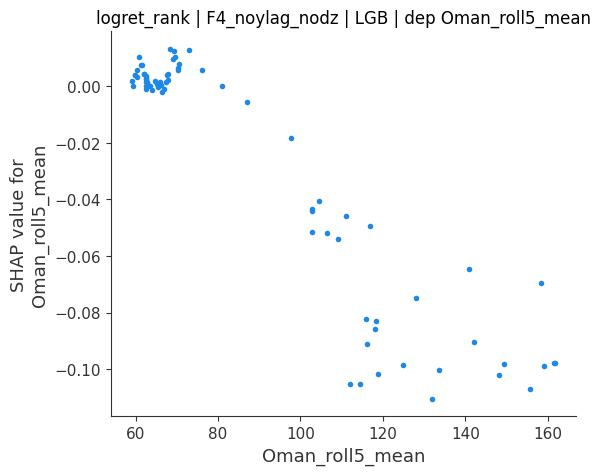

<Figure size 640x480 with 0 Axes>

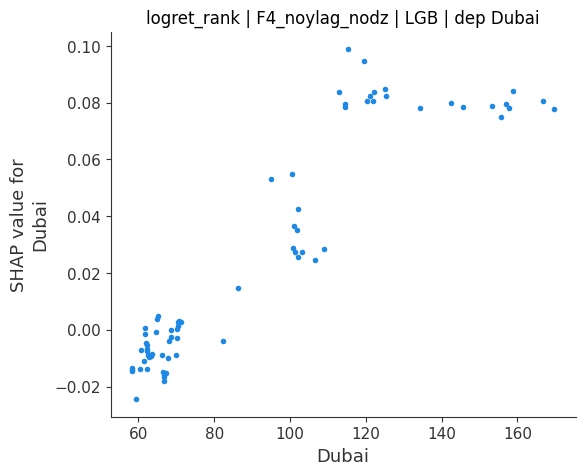

<Figure size 640x480 with 0 Axes>

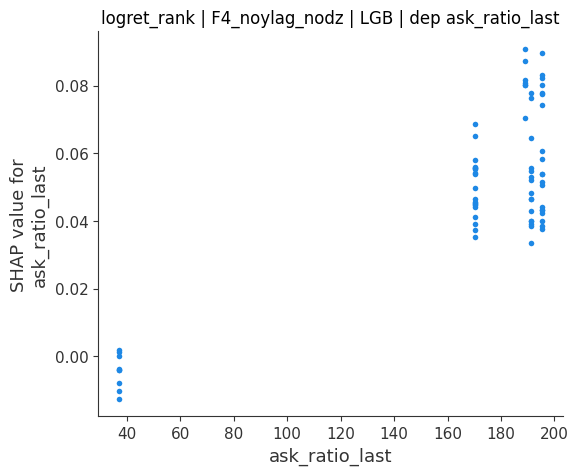

<Figure size 640x480 with 0 Axes>

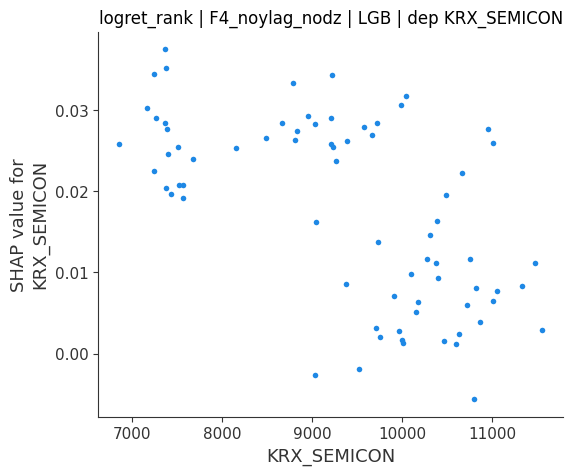

<Figure size 640x480 with 0 Axes>

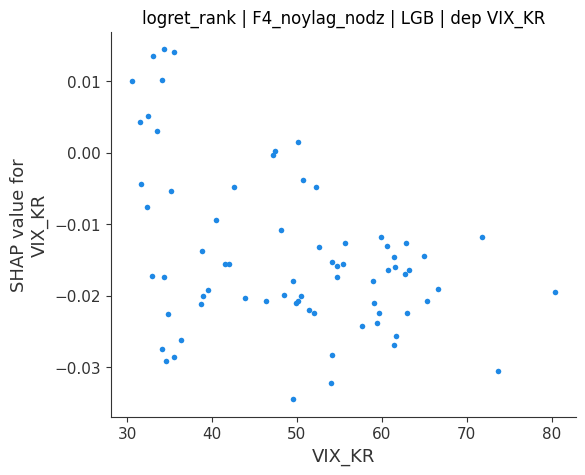

<Figure size 640x480 with 0 Axes>

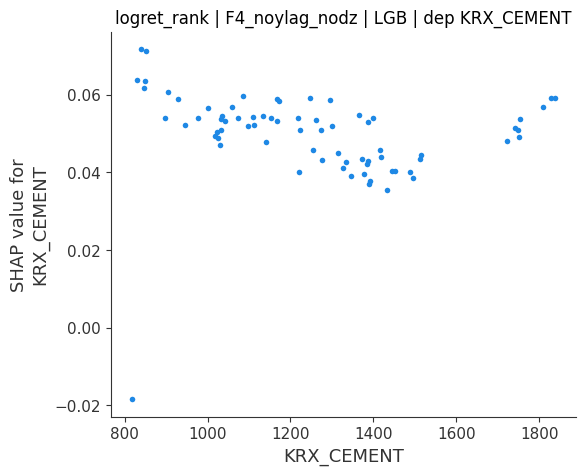

<Figure size 640x480 with 0 Axes>

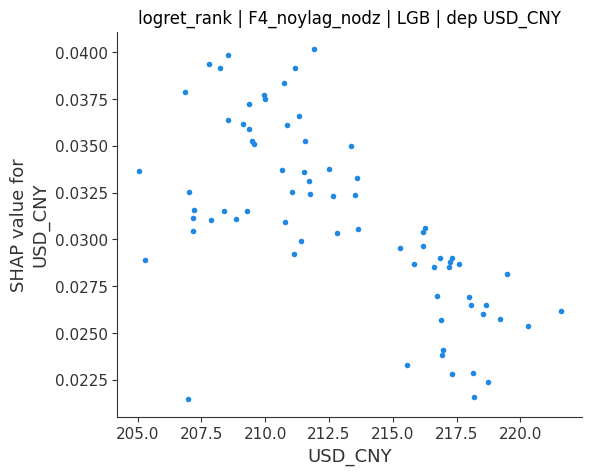

In [8]:
# ---------- 7. Dependence plot — CORE5 강제 + 모델 test top5 ----------
for (target, fset, model), s in shap_store.items():
    sv_te = s['sv_test']; Xte = s['X_test']
    tab_te = shap_share_table(sv_te, list(Xte.columns))
    top5 = tab_te['feature'].head(5).tolist()
    targets_dep = list(dict.fromkeys(CORE5 + top5))
    print(f'{target} | {fset} | {model}: dep targets ({len(targets_dep)}) =', targets_dep)
    for feat in targets_dep:
        if feat not in Xte.columns:
            print(f'  skip (not in X): {feat}'); continue
        plt.figure()
        shap.dependence_plot(feat, sv_te, Xte, interaction_index=None, show=False)
        plt.title(f'{target} | {fset} | {model} | dep {feat}')
        plt.savefig(FIG_DIR / f'dep_{feat}_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
        plt.show()

logret_rank | F4_noylag_nodz | LGB | n_phase2=738 n_phase3=1225 n_phase4_test=72


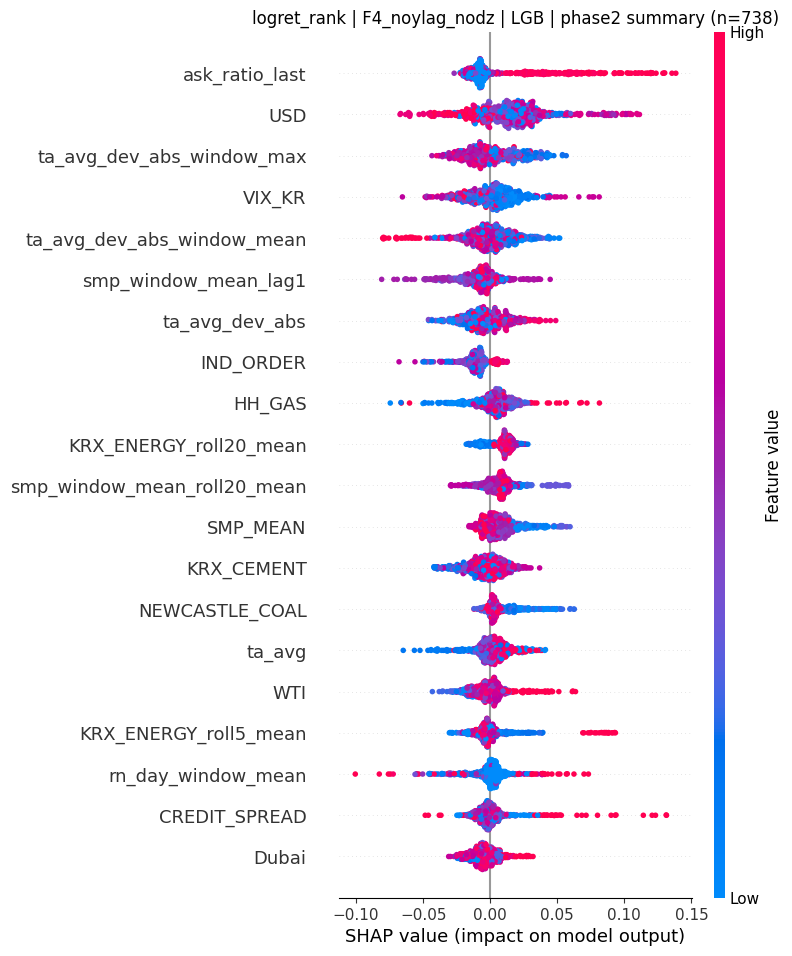

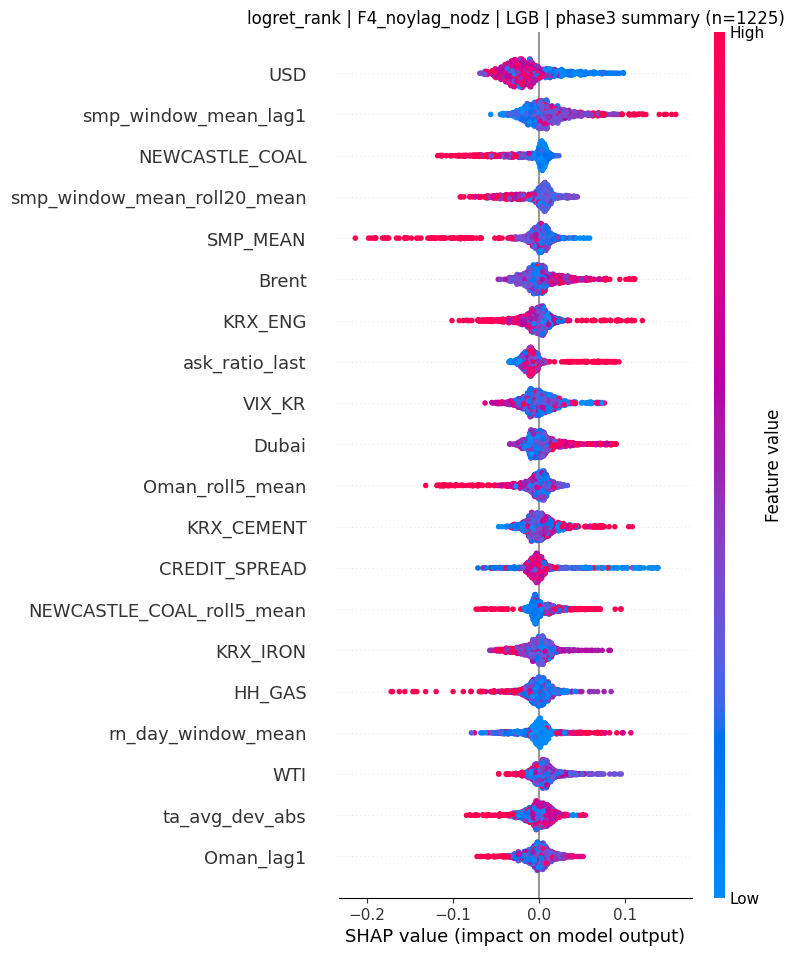

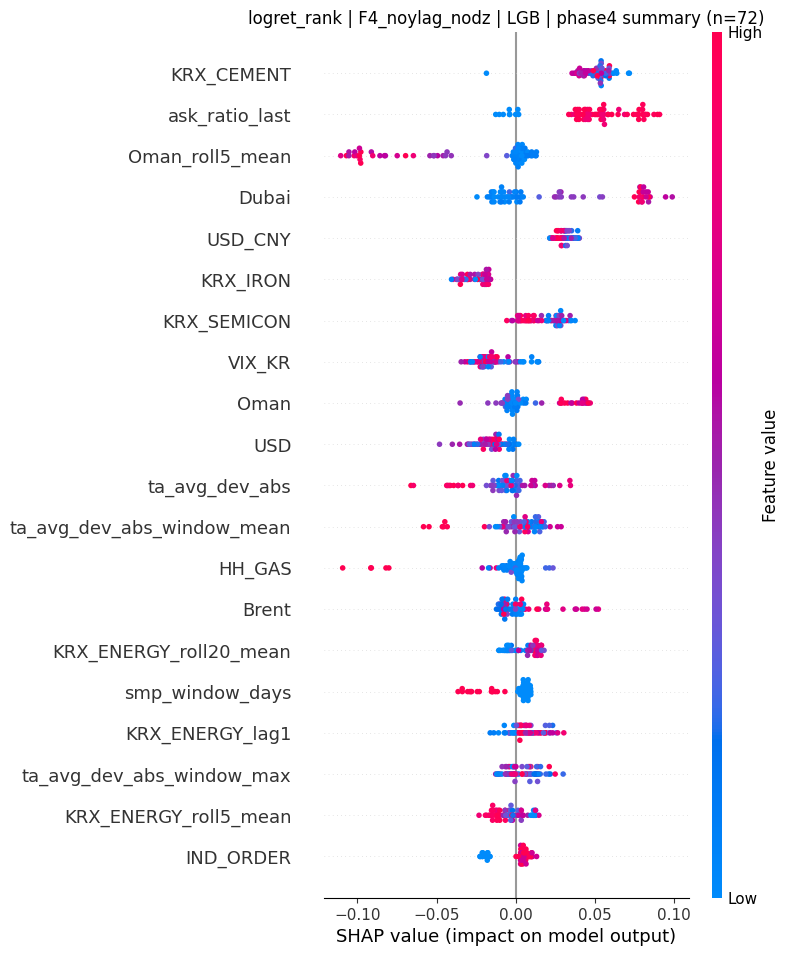

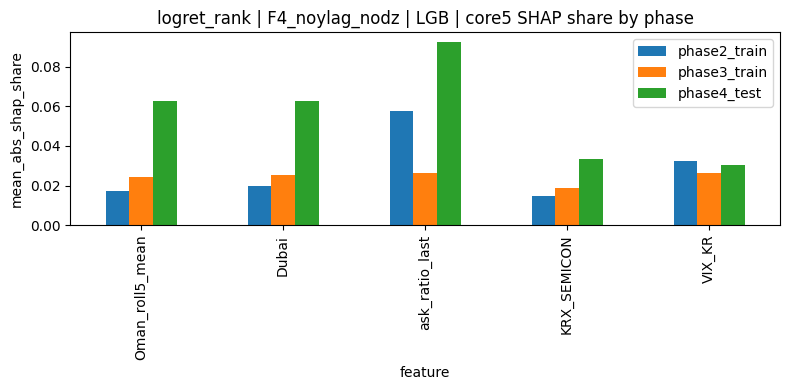

=== core5 phase compare ===


phase2  phase3  phase4
target      fset           model feature                                
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean  0.0172  0.0241  0.0628
                                 Dubai            0.0195  0.0254  0.0626
                                 ask_ratio_last   0.0577  0.0266  0.0927
                                 KRX_SEMICON      0.0148  0.0185  0.0334
                                 VIX_KR           0.0322  0.0261  0.0306

In [9]:
# ---------- 8. phase별 SHAP — train phase2/3 + test phase4 ----------
phase_share_rows = []
for (target, fset, model), s in shap_store.items():
    Xtr = s['X_train']; sv_tr = s['sv_train']
    Xte = s['X_test'];  sv_te = s['sv_test']

    mask_p2_train = (Xtr['phase_phase2'].values == 1)
    mask_p3_train = (Xtr['phase_phase3'].values == 1)
    mask_p4_test  = (Xte['phase_phase4'].values == 1)
    n_p2, n_p3, n_p4 = int(mask_p2_train.sum()), int(mask_p3_train.sum()), int(mask_p4_test.sum())
    print(f'{target} | {fset} | {model} | n_phase2={n_p2} n_phase3={n_p3} n_phase4_test={n_p4}')
    assert n_p4 == len(Xte), 'test 전체가 phase4여야 함'

    sh_p2 = share_under_mask(sv_tr, Xtr, mask_p2_train)[['feature','share']].rename(columns={'share':'phase2_train'})
    sh_p3 = share_under_mask(sv_tr, Xtr, mask_p3_train)[['feature','share']].rename(columns={'share':'phase3_train'})
    sh_p4 = share_under_mask(sv_te, Xte, mask_p4_test)[['feature','share']].rename(columns={'share':'phase4_test'})
    merged = sh_p2.merge(sh_p3, on='feature', how='outer').merge(sh_p4, on='feature', how='outer').fillna(0.0)
    merged.to_csv(OUT_DIR / f'focal_shap_phase_compare_{target}_{fset}_{model}.csv', index=False)

    for label, sv, X, mask in [
        ('phase2', sv_tr, Xtr, mask_p2_train),
        ('phase3', sv_tr, Xtr, mask_p3_train),
        ('phase4', sv_te, Xte, mask_p4_test),
    ]:
        if mask.sum() == 0: continue
        plt.figure()
        shap.summary_plot(np.asarray(sv)[mask], X.iloc[mask], show=False)
        plt.title(f'{target} | {fset} | {model} | {label} summary (n={int(mask.sum())})')
        plt.savefig(FIG_DIR / f'shap_summary_{label}_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
        plt.show()

    sub = merged[merged['feature'].isin(CORE5)].set_index('feature').reindex(CORE5).fillna(0.0)
    ax = sub[['phase2_train','phase3_train','phase4_test']].plot.bar(figsize=(8,4))
    ax.set_title(f'{target} | {fset} | {model} | core5 SHAP share by phase')
    ax.set_ylabel('mean_abs_shap_share')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'shap_phase_bars_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
    plt.show()

    for feat in CORE5:
        if feat in sub.index:
            row = sub.loc[feat]
            phase_share_rows.append({'target': target, 'fset': fset, 'model': model, 'feature': feat,
                                     'phase2': float(row['phase2_train']),
                                     'phase3': float(row['phase3_train']),
                                     'phase4': float(row['phase4_test'])})

phase_core_df = pd.DataFrame(phase_share_rows)
phase_core_df.to_csv(OUT_DIR / 'focal_core5_phase_compare.csv', index=False)
print('=== core5 phase compare ===')
display(phase_core_df.set_index(['target','fset','model','feature']).round(4))

test up/down/zero: 44 18 10
test ~vintage_transition: 72


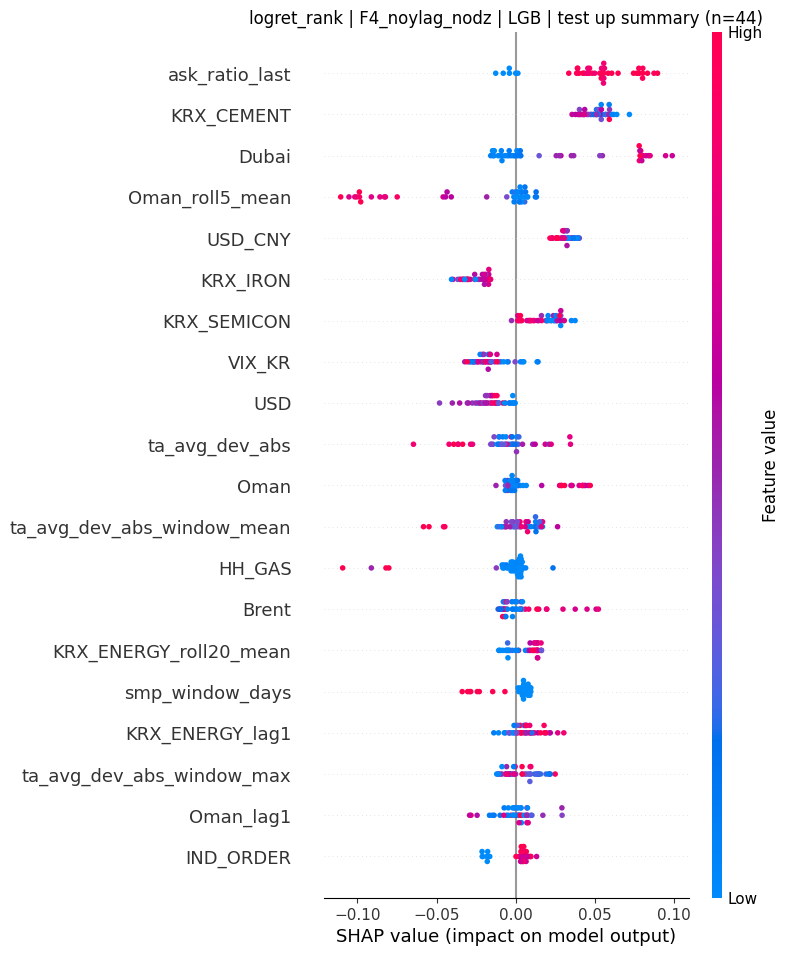

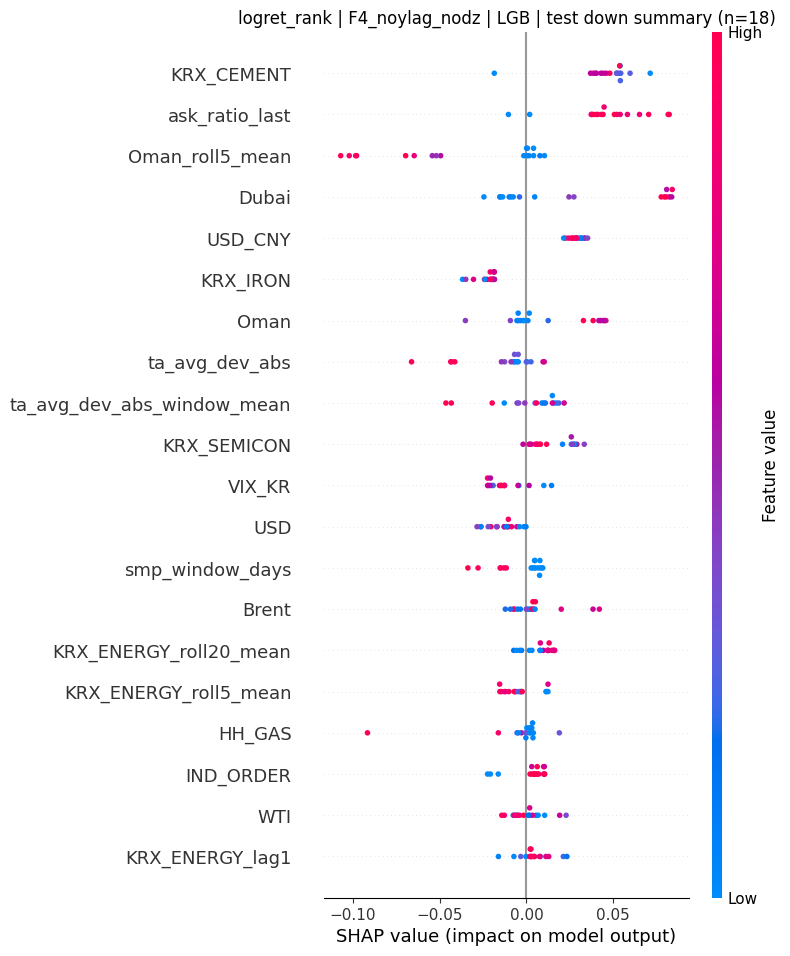

=== core5 up/down compare (test) ===


test_full  test_up  \
target      fset           model feature                               
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean     0.0628   0.0599   
                                 Dubai               0.0626   0.0628   
                                 ask_ratio_last      0.0927   0.0937   
                                 KRX_SEMICON         0.0334   0.0332   
                                 VIX_KR              0.0306   0.0316   

                                                  test_down  updown_diff_abs  
target      fset           model feature                                      
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean     0.0762           0.0163  
                                 Dubai               0.0761           0.0132  
                                 ask_ratio_last      0.0896           0.0041  
                                 KRX_SEMICON         0.0283           0.0049  
                                 VIX_KR              0.0279           0.0037

In [10]:
# ---------- 9. 상승/하락일 분리 SHAP (test) ----------
ret_test = df_test['ret_1d_raw'].values
mask_up = ret_test > 0
mask_down = ret_test < 0
vt_test = df_test['vintage_transition'].values.astype(bool)
mask_no_tr = ~vt_test
print('test up/down/zero:', int(mask_up.sum()), int(mask_down.sum()), int((ret_test == 0).sum()))
print('test ~vintage_transition:', int(mask_no_tr.sum()))

updown_rows = []
for (target, fset, model), s in shap_store.items():
    sv_te = s['sv_test']; Xte = s['X_test']
    sh_up = share_under_mask(sv_te, Xte, mask_up)[['feature','share']].rename(columns={'share':'test_up'})
    sh_dn = share_under_mask(sv_te, Xte, mask_down)[['feature','share']].rename(columns={'share':'test_down'})
    full = shap_share_table(sv_te, list(Xte.columns))[['feature','mean_abs_shap_share']]\
             .rename(columns={'mean_abs_shap_share':'test_full'})
    merged = full.merge(sh_up, on='feature', how='outer').merge(sh_dn, on='feature', how='outer').fillna(0.0)
    merged.to_csv(OUT_DIR / f'focal_shap_updown_{target}_{fset}_{model}.csv', index=False)

    for label, mask in [('up', mask_up), ('down', mask_down)]:
        if mask.sum() == 0: continue
        plt.figure()
        shap.summary_plot(np.asarray(sv_te)[mask], Xte.iloc[mask], show=False)
        plt.title(f'{target} | {fset} | {model} | test {label} summary (n={int(mask.sum())})')
        plt.savefig(FIG_DIR / f'shap_summary_{label}_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
        plt.show()

    sub = merged[merged['feature'].isin(CORE5)].set_index('feature').reindex(CORE5).fillna(0.0)
    for feat, row in sub.iterrows():
        updown_rows.append({'target': target, 'fset': fset, 'model': model, 'feature': feat,
                            'test_full': float(row['test_full']),
                            'test_up':   float(row['test_up']),
                            'test_down': float(row['test_down']),
                            'updown_diff_abs': abs(float(row['test_up']) - float(row['test_down']))})

updown_core_df = pd.DataFrame(updown_rows)
updown_core_df.to_csv(OUT_DIR / 'focal_core5_updown_compare.csv', index=False)
print('=== core5 up/down compare (test) ===')
display(updown_core_df.set_index(['target','fset','model','feature']).round(4))

=== focal_5vars_master ===


phase2_train  phase3_train  \
target      fset           model feature                                       
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean        0.0172        0.0241   
                                 Dubai                  0.0195        0.0254   
                                 ask_ratio_last         0.0577        0.0266   
                                 KRX_SEMICON            0.0148        0.0185   
                                 VIX_KR                 0.0322        0.0261   

                                                  phase4_test  test_up  \
target      fset           model feature                                 
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean       0.0628   0.0599   
                                 Dubai                 0.0626   0.0628   
                                 ask_ratio_last        0.0927   0.0937   
                                 KRX_SEMICON           0.0334   0.0332   
                                 VIX_KR                0.0306   0.0316   

                                                  test_down  \
target      fset           model feature                      
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean     0.0762   
                                 Dubai               0.0761   
                                 ask_ratio_last      0.0896   
                                 KRX_SEMICON         0.0283   
                                 VIX_KR              0.0279   

                                                  test_no_transition  
target      fset           model feature                              
logret_rank F4_noylag_nodz LGB   Oman_roll5_mean              0.0628  
                                 Dubai                        0.0626  
                                 ask_ratio_last               0.0927  
                                 KRX_SEMICON                  0.0334  
                                 VIX_KR                       0.0306

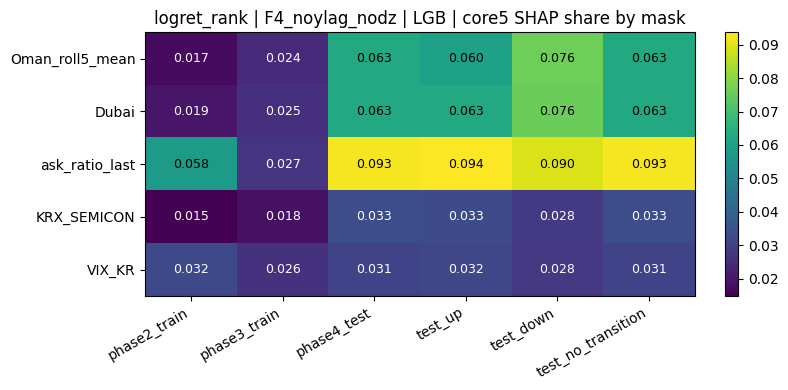

In [11]:
# ---------- 10. 통합 master 표 + heatmap (5변수 x 6 마스크) ----------
master_rows = []
for (target, fset, model), s in shap_store.items():
    sv_tr = s['sv_train']; Xtr = s['X_train']
    sv_te = s['sv_test'];  Xte = s['X_test']

    masks = {
        'phase2_train':       (Xtr['phase_phase2'].values == 1, sv_tr, Xtr),
        'phase3_train':       (Xtr['phase_phase3'].values == 1, sv_tr, Xtr),
        'phase4_test':        (np.ones(len(Xte), dtype=bool),    sv_te, Xte),
        'test_up':            (mask_up,                          sv_te, Xte),
        'test_down':          (mask_down,                        sv_te, Xte),
        'test_no_transition': (mask_no_tr,                       sv_te, Xte),
    }
    feat_to_share = {feat: {} for feat in CORE5}
    for label, (mask, sv, X) in masks.items():
        if mask.sum() == 0:
            for feat in CORE5: feat_to_share[feat][label] = np.nan
            continue
        tab = share_under_mask(sv, X, mask)
        m = tab.set_index('feature')['share']
        for feat in CORE5:
            feat_to_share[feat][label] = float(m.get(feat, 0.0))
    for feat, d in feat_to_share.items():
        master_rows.append({'target': target, 'fset': fset, 'model': model, 'feature': feat, **d})

master_df = pd.DataFrame(master_rows)
master_df.to_csv(OUT_DIR / 'focal_5vars_master.csv', index=False)
print('=== focal_5vars_master ===')
display(master_df.set_index(['target','fset','model','feature']).round(4))

mask_cols = ['phase2_train','phase3_train','phase4_test','test_up','test_down','test_no_transition']
for (target, fset, model), _ in focal.items():
    sub = master_df[(master_df['target']==target) & (master_df['fset']==fset) & (master_df['model']==model)]\
            .set_index('feature')[mask_cols].reindex(CORE5)
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(sub.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(mask_cols))); ax.set_xticklabels(mask_cols, rotation=30, ha='right')
    ax.set_yticks(range(len(CORE5))); ax.set_yticklabels(CORE5)
    vmax = np.nanmax(sub.values) if np.isfinite(np.nanmax(sub.values)) else 1.0
    for i in range(len(CORE5)):
        for j in range(len(mask_cols)):
            v = sub.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                        color='white' if v < vmax*0.5 else 'black', fontsize=9)
    ax.set_title(f'{target} | {fset} | {model} | core5 SHAP share by mask')
    fig.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'heatmap_core5_{target}_{fset}_{model}.png', dpi=120, bbox_inches='tight')
    plt.show()

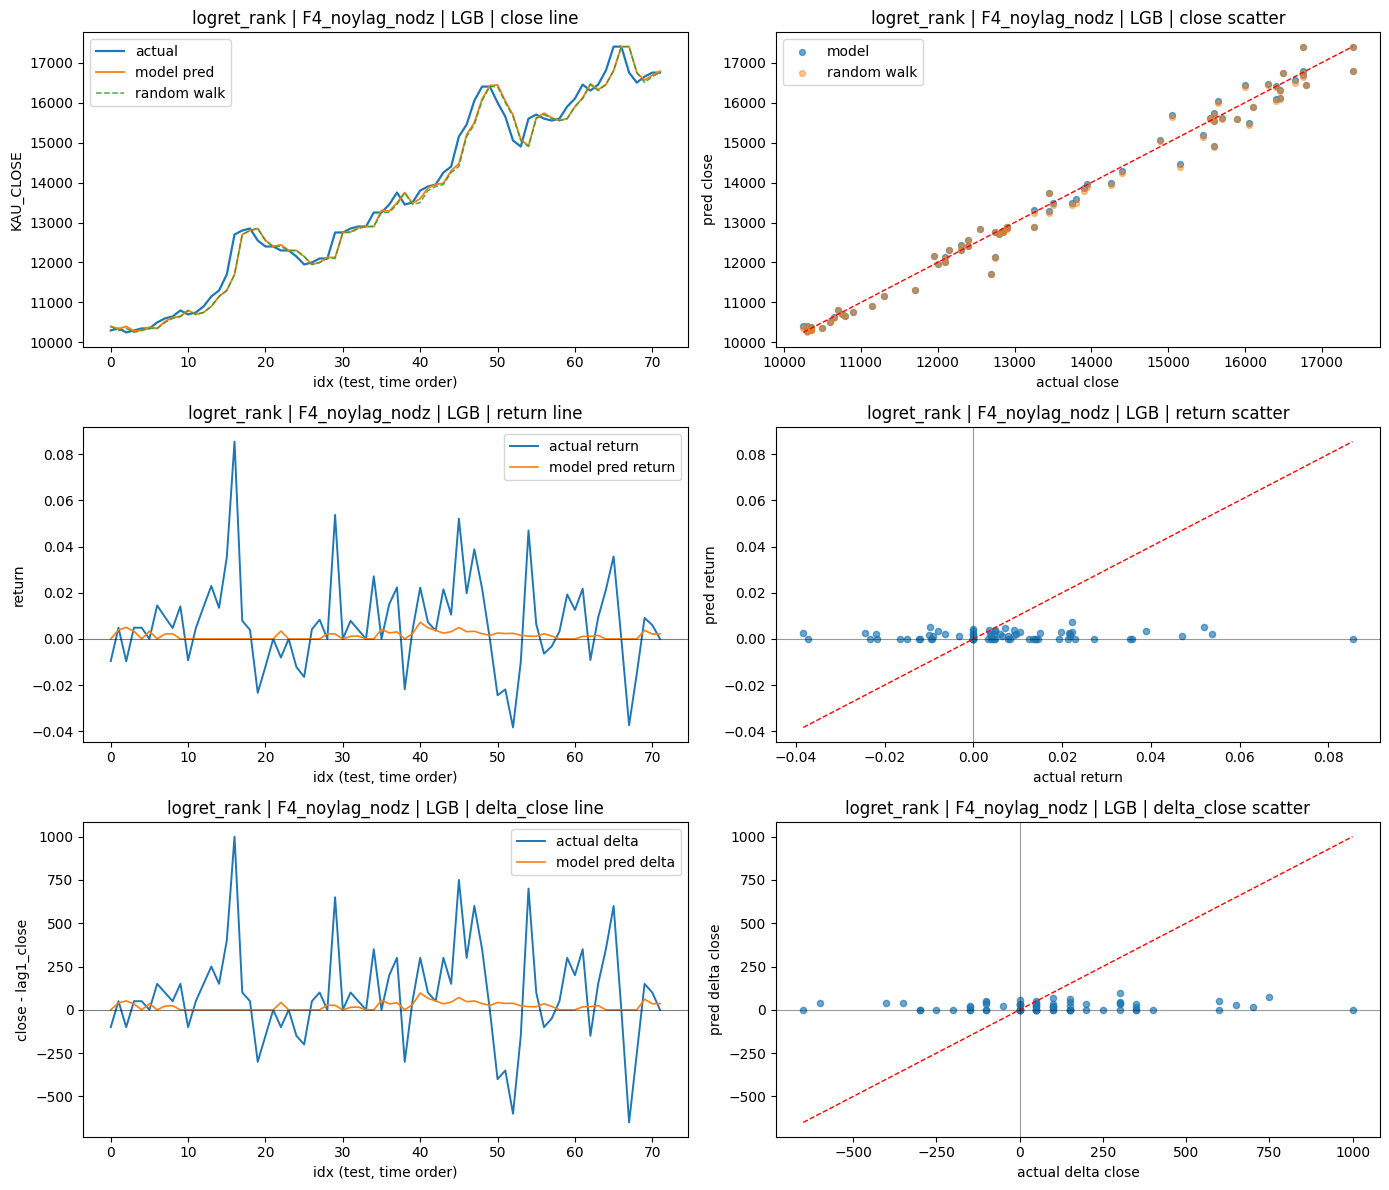

,target,fset,model,close_MAE,rw_close_MAE,close_MAE_vs_RW_ratio,ret_MAE,delta_MAE,direction_acc,pred_ret_zero_ratio_abs_lt_1e-12,pred_delta_zero_ratio_abs_lt_1e-9
0,logret_rank,F4_noylag_nodz,LGB,198.353754,204.861111,0.968235,0.014362,198.353754,0.416667,0.458333,0.458333


In [12]:
# ---------- 11. Diagnostic plots: model vs random walk / return / delta ----------
diag_rows = []
actual_close = df_test['KAU_CLOSE'].values.reshape(-1)
lag1_close = df_test['KAU_CLOSE_lag1'].values.reshape(-1)
actual_ret = actual_close / lag1_close - 1.0
actual_delta = actual_close - lag1_close
rw_close = lag1_close.copy()

for (target, fset, model), r in focal.items():
    pred_close = np.asarray(r['pred_close_test']).reshape(-1)
    pred_ret = pred_close / lag1_close - 1.0
    pred_delta = pred_close - lag1_close

    close_mae = float(np.mean(np.abs(actual_close - pred_close)))
    rw_close_mae = float(np.mean(np.abs(actual_close - rw_close)))
    ret_mae = float(np.mean(np.abs(actual_ret - pred_ret)))
    delta_mae = float(np.mean(np.abs(actual_delta - pred_delta)))
    dir_acc = float(np.mean(np.sign(actual_delta) == np.sign(pred_delta)))

    diag_rows.append({
        'target': target, 'fset': fset, 'model': model,
        'close_MAE': close_mae,
        'rw_close_MAE': rw_close_mae,
        'close_MAE_vs_RW_ratio': close_mae / rw_close_mae if rw_close_mae > 0 else np.nan,
        'ret_MAE': ret_mae,
        'delta_MAE': delta_mae,
        'direction_acc': dir_acc,
        'pred_ret_zero_ratio_abs_lt_1e-12': float(np.mean(np.abs(pred_ret) < 1e-12)),
        'pred_delta_zero_ratio_abs_lt_1e-9': float(np.mean(np.abs(pred_delta) < 1e-9)),
    })

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    ax = axes[0, 0]
    ax.plot(actual_close, label='actual', lw=1.6)
    ax.plot(pred_close, label='model pred', lw=1.3)
    ax.plot(rw_close, label='random walk', lw=1.1, ls='--', alpha=0.85)
    ax.set_title(f'{target} | {fset} | {model} | close line')
    ax.set_xlabel('idx (test, time order)'); ax.set_ylabel('KAU_CLOSE'); ax.legend()

    ax = axes[0, 1]
    ax.scatter(actual_close, pred_close, s=18, alpha=0.65, label='model')
    ax.scatter(actual_close, rw_close, s=18, alpha=0.45, label='random walk')
    lo = min(actual_close.min(), pred_close.min(), rw_close.min())
    hi = max(actual_close.max(), pred_close.max(), rw_close.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'{target} | {fset} | {model} | close scatter')
    ax.set_xlabel('actual close'); ax.set_ylabel('pred close'); ax.legend()

    ax = axes[1, 0]
    ax.plot(actual_ret, label='actual return', lw=1.4)
    ax.plot(pred_ret, label='model pred return', lw=1.2)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(f'{target} | {fset} | {model} | return line')
    ax.set_xlabel('idx (test, time order)'); ax.set_ylabel('return'); ax.legend()

    ax = axes[1, 1]
    ax.scatter(actual_ret, pred_ret, s=20, alpha=0.65)
    lo = min(actual_ret.min(), pred_ret.min()); hi = max(actual_ret.max(), pred_ret.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.axhline(0, color='black', lw=0.8, alpha=0.4); ax.axvline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_title(f'{target} | {fset} | {model} | return scatter')
    ax.set_xlabel('actual return'); ax.set_ylabel('pred return')

    ax = axes[2, 0]
    ax.plot(actual_delta, label='actual delta', lw=1.4)
    ax.plot(pred_delta, label='model pred delta', lw=1.2)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(f'{target} | {fset} | {model} | delta_close line')
    ax.set_xlabel('idx (test, time order)'); ax.set_ylabel('close - lag1_close'); ax.legend()

    ax = axes[2, 1]
    ax.scatter(actual_delta, pred_delta, s=20, alpha=0.65)
    lo = min(actual_delta.min(), pred_delta.min()); hi = max(actual_delta.max(), pred_delta.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.axhline(0, color='black', lw=0.8, alpha=0.4); ax.axvline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_title(f'{target} | {fset} | {model} | delta_close scatter')
    ax.set_xlabel('actual delta close'); ax.set_ylabel('pred delta close')

    plt.tight_layout()
    save_path = FIG_DIR / f'diagnostic_rw_return_delta_{target}_{fset}_{model}.png'
    plt.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT_DIR / 'focal_diagnostic_rw_return_delta_metrics.csv', index=False)
display(diag_df.round(6))